# ADEPT Architectural Analysis Journey: Toy Example
This notebook provides a comprehensive walkthrough of the ADEPT framework's analysis pipeline.

In [2]:
%matplotlib inline

# Set project root in path so we can import 'adept' package
import sys
sys.path.append("../../")

import os
import json
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from adept import PatternAnalysis

## 1. Initialize and Load Data

In [4]:
json_path = "ArchExample_Discretization.json"
session = PatternAnalysis(json_path)

# Load both definition and data
session.load(validate_integrity=True)

print(f"Loaded {len(session.raw_df)} experiments.")
session.raw_df # .head()

Data integrity validation passed successfully.
Loaded 171000 experiments.


/Users/adiazpace/Documents/GitHub/patterns-sa/patterns/Toy_Example/../../adept/core/loader.py:228: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[param] = df[param].mask(mapped_values.notna(), mapped_values)
/Users/adiazpace/Documents/GitHub/patterns-sa/patterns/Toy_Example/../../adept/core/loader.py:228: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, s

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services,scenario,policy,model,cost,executionTime,probSuccessfulExecution,policy_config
0,109,23,49,27,5,18,0,0,1,343,1,archexploration,28,94,60,0_0_1
1,138,15,18,22,4,10,0,0,1,344,1,archexploration,19,81,71,0_0_1
2,104,21,44,30,3,48,0,0,1,345,1,archexploration,24,72,37,0_0_1
3,109,12,11,15,3,36,0,0,1,346,1,archexploration,15,46,55,0_0_1
4,147,13,11,18,1,27,0,0,1,347,1,archexploration,14,65,60,0_0_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170995,105,1,22,16,5,11,6,6,6,838,342,archexploration,93,38,84,6_6_6
170996,125,36,13,14,3,17,6,6,6,839,342,archexploration,162,31,86,6_6_6
170997,114,17,27,17,5,49,6,6,6,840,342,archexploration,141,37,74,6_6_6
170998,107,14,11,28,5,30,6,6,6,841,342,archexploration,132,24,71,6_6_6


## 2. Define Tradeoffs (Programmatic Fallback)

In [17]:
session.clear_tradeoffs()

In [18]:
if not session.get_tradeoffs():
    print("No tradeoffs defined in JSON. Defining programmatically...")
    session.add_tradeoff(
        name="Inexpensive-but-reliable",
        elements={"cost": "low", "probSuccessfulExecution": "high"}
    )
    session.add_tradeoff(
        name="Fast-and-reliable",
        elements={"executionTime": "low", "probSuccessfulExecution": "high"}
    )

# Discretize outcomes
target_labels = {qa.name: ["low", "avg", "high"] for qa in session.get_outcomes()}
discrete_df, schemes = session.define_tradeoffs(n_bins=3, labels=target_labels, method='discretization')

for scheme in schemes:
    print(f"Objective: {scheme.objective_name}")
    for b in scheme.bins:
        print(f"  {b.label}: [{b.min_value:.2f}, {b.max_value:.2f}]")

No tradeoffs defined in JSON. Defining programmatically...
Objective: cost
  low: [0.90, 70.63]
  avg: [70.63, 140.37]
  high: [140.37, 210.10]
Objective: executionTime
  low: [21.90, 52.63]
  avg: [52.63, 83.37]
  high: [83.37, 114.10]
Objective: probSuccessfulExecution
  low: [25.90, 47.30]
  avg: [47.30, 68.70]
  high: [68.70, 90.10]


## 3. Data Splitting

In [6]:
session.split_data(test_size=0.2)
print(f"Train size: {len(session.train_indices)}")
print(f"Test size: {len(session.test_indices)}")

Data split: 136800 train, 34200 test.
Train size: 136800
Test size: 34200


## 4. Outcome Distributions

Plotting distribution for: Inexpensive-but-reliable


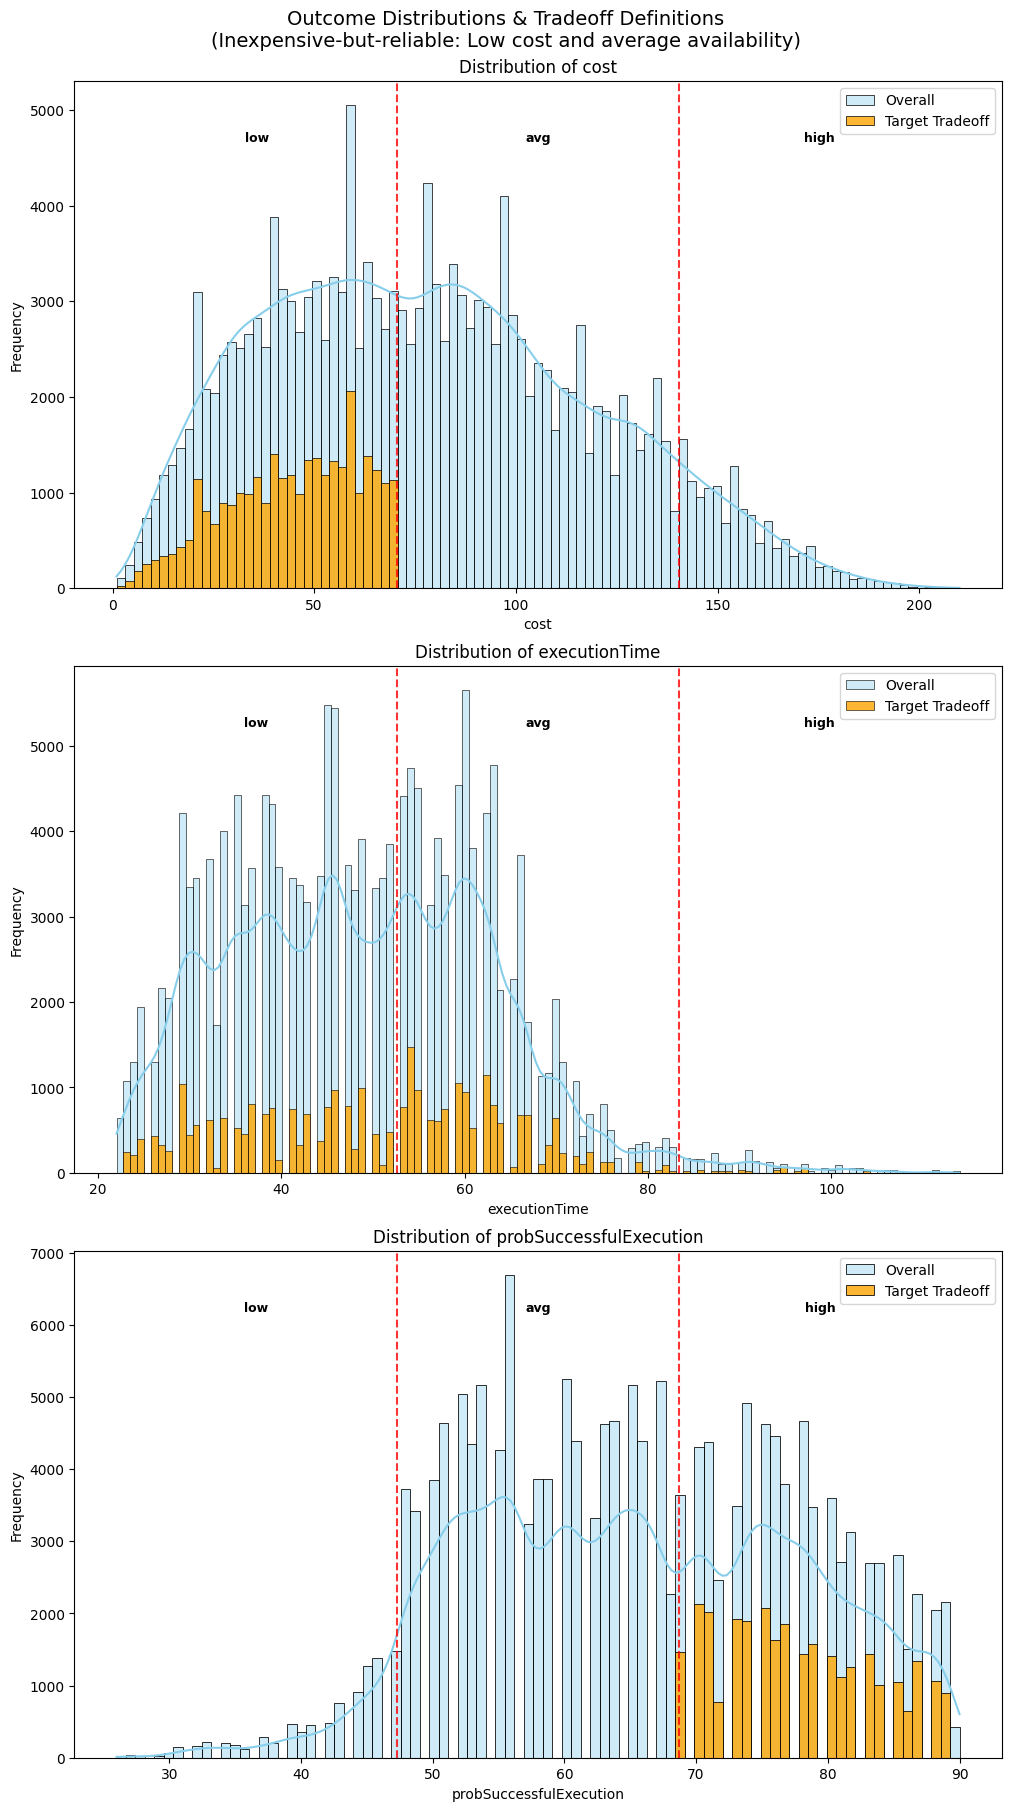

Plotting distribution for: Fast-and-reliable


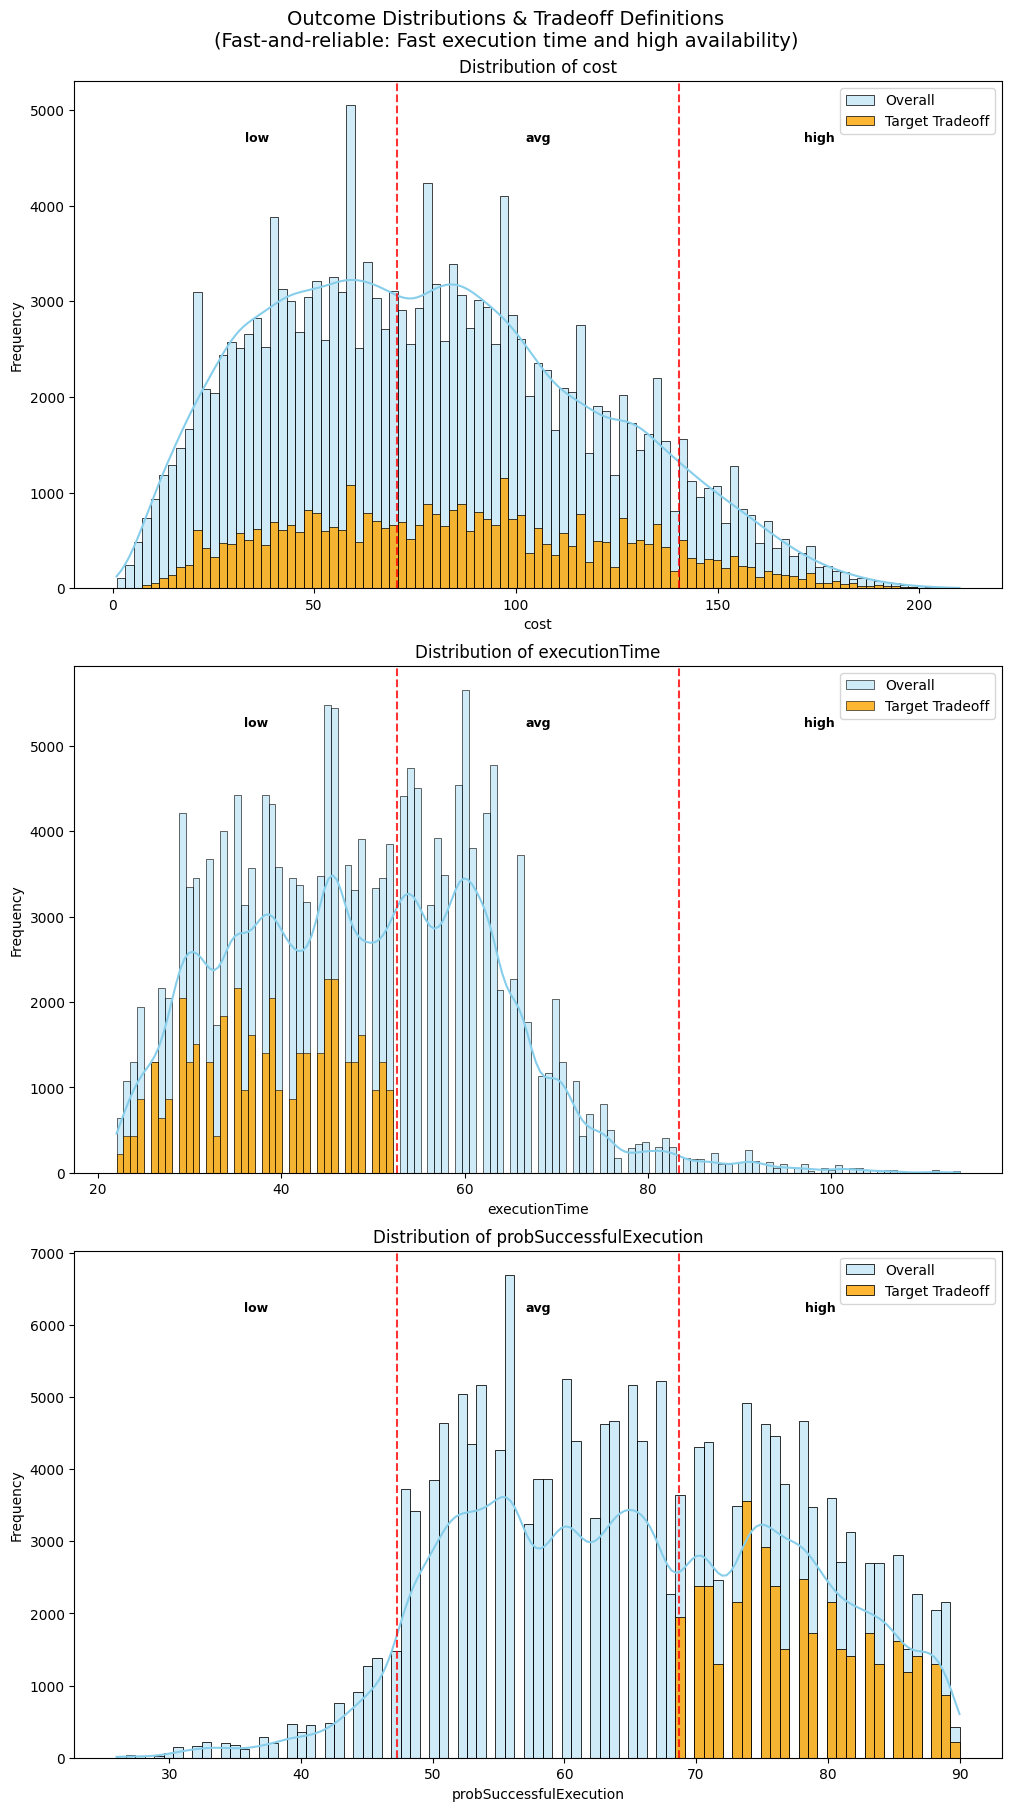

In [8]:
%matplotlib inline

for tradeoff in session.get_tradeoffs():
    indices = session.get_indices_for_tradeoff(tradeoff)
    print(f"Plotting distribution for: {tradeoff.name}")
    session.coordinator.plot_distributions(
        session.outcomes_df, 
        schemes, 
        tradeoff=tradeoff,
        highlight_indices=indices
    )
    plt.show()

## 5. Quality Objective Space (2D Scatter)

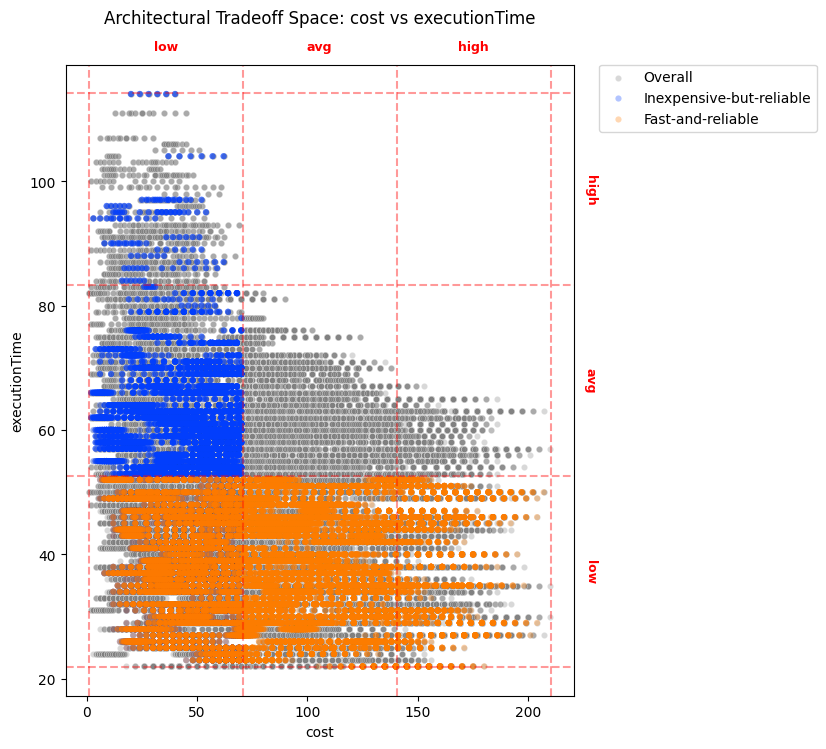

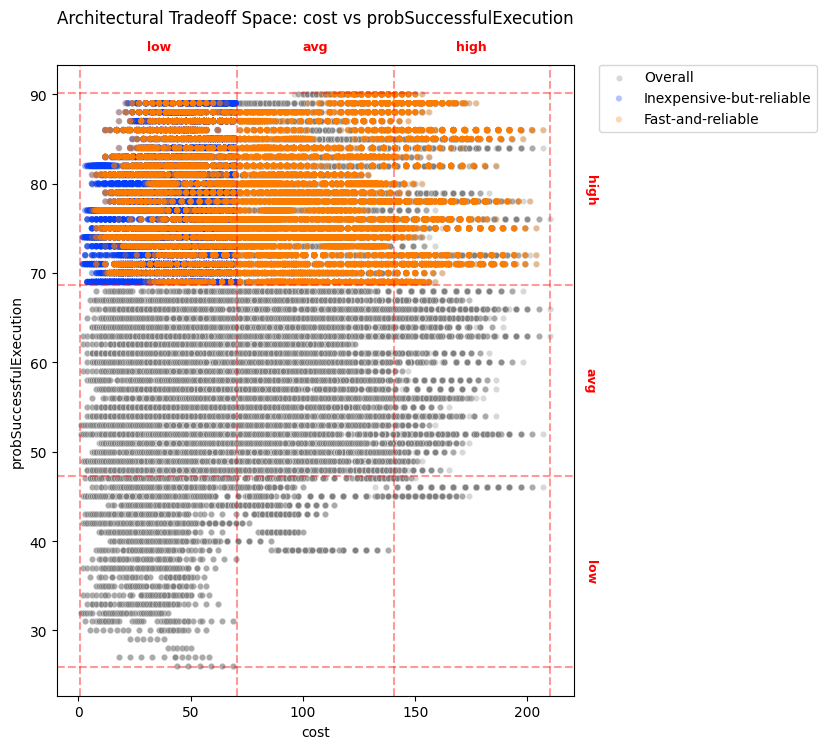

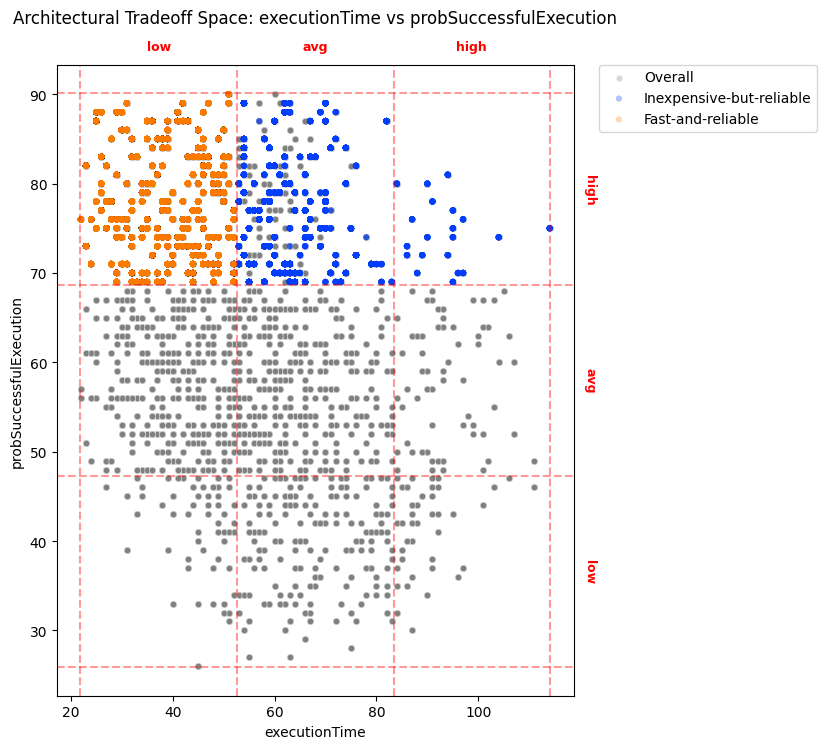

In [9]:
outcome_cols = list(session.outcomes_df.columns)
for x_col, y_col in itertools.combinations(outcome_cols, 2):
    session.show_quality_objective_space(
        x_col, y_col, 
        highlight_tradeoffs=session.get_tradeoffs(),
        show_overall=True,
        subset='all'
    )
    plt.show()

## 6. Contingency Analysis

Analyzing Decision: arch_example_pattern:deployment_strategy


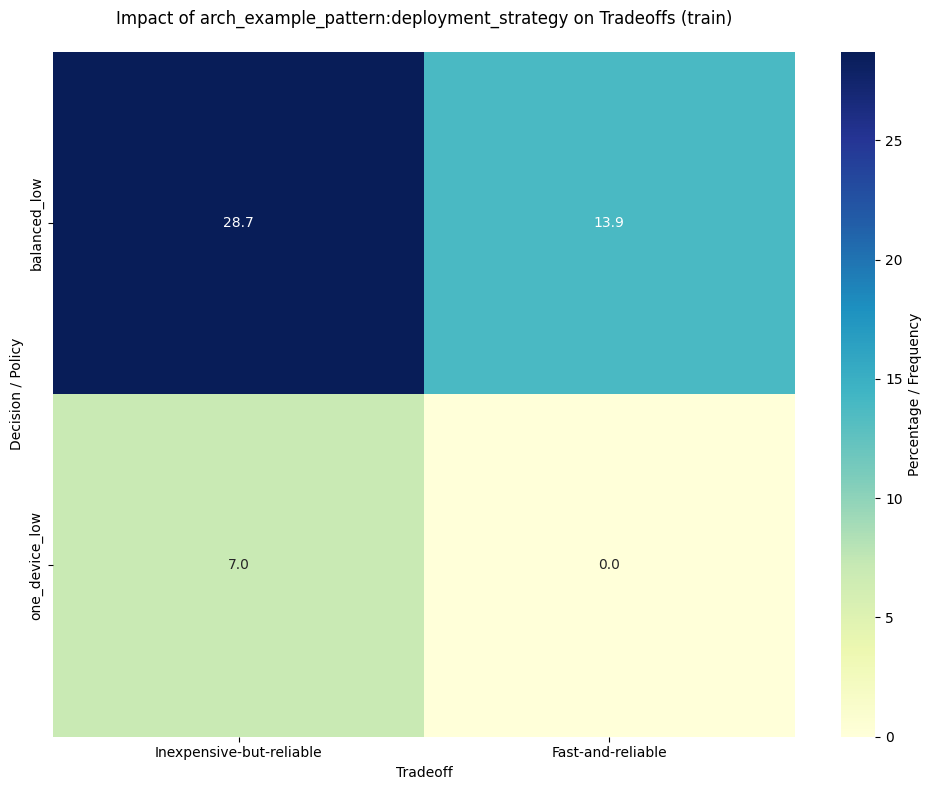

In [10]:
decisions = list(session.get_decisions().keys())
for decision_key in decisions:
    print(f"Analyzing Decision: {decision_key}")
    session.show_policy_contingency(decision_key, type='heatmap', subset='train')
    plt.show()

## 7. Robustness Analysis

Robustness Ranking for Tradeoff: Inexpensive-but-reliable
  1. balanced_low: 0.29% success
  2. one_device_low: 0.07% success
  Top Policy 'balanced_low' Regret: 0.6828
Robustness Ranking for Tradeoff: Fast-and-reliable
  1. balanced_low: 0.15% success
  2. one_device_low: 0.00% success
  Top Policy 'balanced_low' Regret: 0.9153

Overall Robustness Heatmap (STARR) - The higher the better:


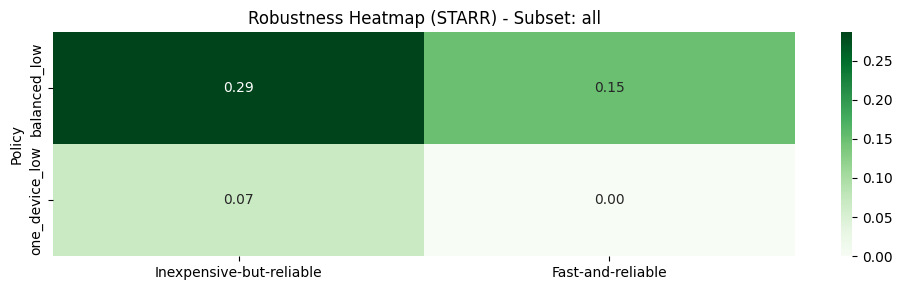


Overall Robustness Heatmap (REGRET) - The lower the better:


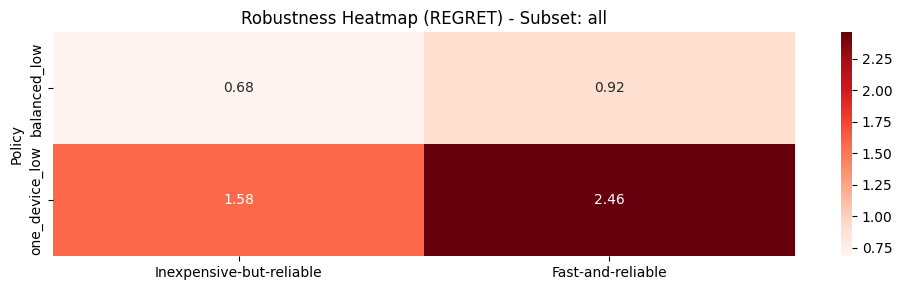

In [16]:
for tradeoff in session.get_tradeoffs():
    print(f"Robustness Ranking for Tradeoff: {tradeoff.name}")
    ranking = session.get_policy_robustness_ranking(tradeoff.name, metric='starr')
    for i, (pol, val) in enumerate(ranking[:3]):
        print(f"  {i+1}. {pol}: {val:.2f}% success")
    
    if ranking:
        top_pol = ranking[0][0]
        regret = session.compute_robustness(top_pol, tradeoff.name, metric='regret')
        print(f"  Top Policy '{top_pol}' Regret: {regret.get('value', 0.0):.4f}")

print("\nOverall Robustness Heatmap (STARR) - The higher the better:")
session.show_robustness_heatmap(metric='starr')
plt.show()
print("\nOverall Robustness Heatmap (REGRET) - The lower the better:")
session.show_robustness_heatmap(metric='regret')
plt.show()

## 8. Feature Importance

Scoring features for outcome: cost (on subset: train)
Scoring features for outcome: executionTime (on subset: train)
Scoring features for outcome: probSuccessfulExecution (on subset: train)


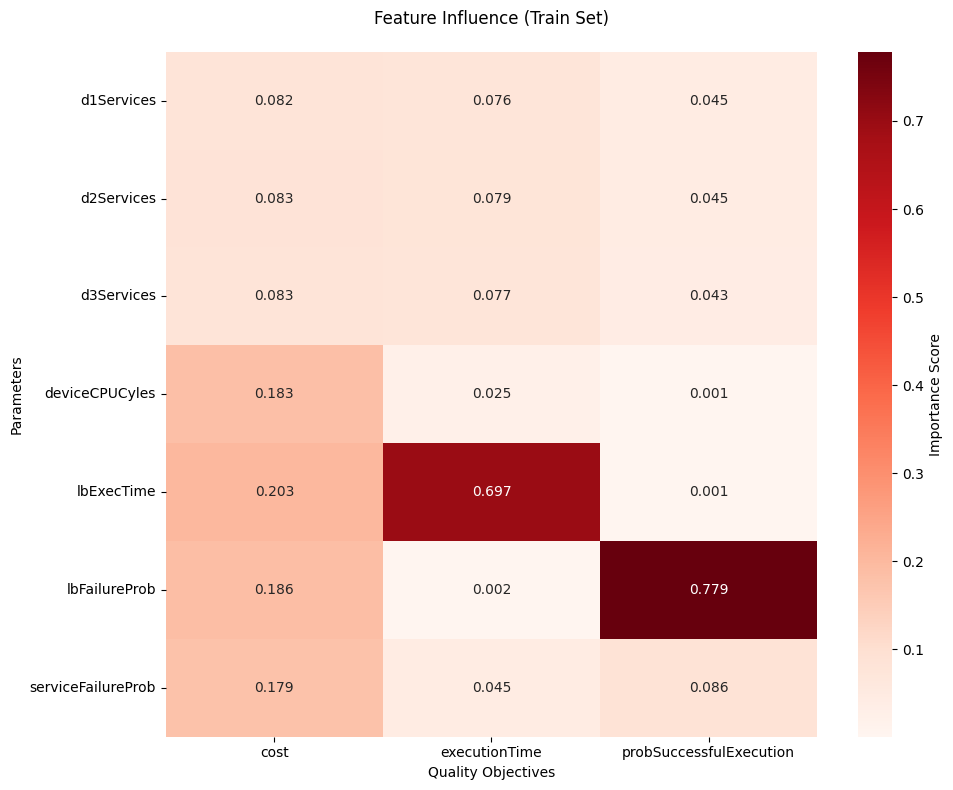

In [12]:
scores_df = session.compute_feature_scores(use_smart_correlation=True, subset='train')

session.show_feature_heatmap(scores_df, title="Feature Influence (Train Set)")
plt.show()

## 9. Scenario Discovery (PRIM)

In [ ]:
for tradeoff in session.get_tradeoffs():
    print("-"*10)
    print(f"Discovering scenarios for: {tradeoff.name}")
    boxes = session.discover_scenarios(tradeoff.name, method='prim', threshold=0.7, standardize=True)
    if boxes:
        best_box = boxes[0]
        print(f"  Key Rules: {best_box.limits}")
        print(f"  Metrics: {best_box.metrics}")
    else:
        print("  No stable scenarios discovered.")

Discovering scenarios for: Inexpensive-but-reliable
Running PRIM discovery for: Inexpensive-but-reliable ...
Instances satisfying property: False    112797
True      24003
Name: count, dtype: int64
Total instances: (136800, 9)
Running PRIM ... rhodium


/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat([self.peeling_trajectory, pd.DataFrame([stats])],
/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat([self.peeling_trajectory, pd.DataFrame([stats])],
/Users/adiazpace/opt/anaconda3/envs/perf

10 possible boxes
  Key Rules: {'d1Services': {'min': 0.5, 'max': 6.0}, 'deviceCost': {'min': 0.0, 'max': 13.5}, 'serviceCost': {'min': 1.0000000000000002, 'max': 3.5}, 'lbFailureProb': {'min': 10.0, 'max': 26.5}, 'serviceFailureProb': {'min': 10.0, 'max': 42.0}, 'd3Services': {'min': 0.5, 'max': 6.0}}
  Metrics: {'density': 0.9798770262716602, 'coverage': 0.29211798033661057, 'population_prevalence': 0.17546052631578948, 'lift': 5.5846009746266345, 'samples_in_box': 1789, 'targets_in_box': 1753}
Discovering scenarios for: Fast-and-reliable
Running PRIM discovery for: Fast-and-reliable ...
Instances satisfying property: False    105264
True      31536
Name: count, dtype: int64
Total instances: (136800, 9)
Running PRIM ... rhodium


/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat([self.peeling_trajectory, pd.DataFrame([stats])],
/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat([self.peeling_trajectory, pd.DataFrame([stats])],
/Users/adiazpace/opt/anaconda3/envs/perf

7 possible boxes
  Key Rules: {'d1Services': {'min': 0.5, 'max': 6.0}, 'd2Services': {'min': 0.5, 'max': 6.0}, 'lbExecTime': {'min': 10.0, 'max': 33.5}, 'lbFailureProb': {'min': 10.0, 'max': 25.5}, 'serviceFailureProb': {'min': 11.5, 'max': 48.5}, 'd3Services': {'min': 0.5, 'max': 6.0}}
  Metrics: {'density': 1.0, 'coverage': 0.5227042110603755, 'population_prevalence': 0.2305263157894737, 'lift': 4.337899543378995, 'samples_in_box': 4121, 'targets_in_box': 4121}


/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat([self.peeling_trajectory, pd.DataFrame([stats])],
/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:783: RuntimeWarning: invalid value encountered in scalar divide
  p = Hj/Tj


## 10. Global Discovery (CART)

In [ ]:
boxes_cart = session.discover_scenarios(method='cart', standardize=False)
for box in boxes_cart:
    if box.metrics.get('targets_in_box', 0) > 10: # Threshold for datapoints in box
        print(f"Box for {box.target_tradeoff}: {box.limits}")

Running CART global discovery for all tradeoff combinations ...
Box for avg,low,high: {'d1Services': {'min': 0.500000001, 'max': inf}, 'd2Services': {'min': 0.500000001, 'max': inf}, 'deviceCost': {'min': 21.500000001, 'max': 32.5}, 'serviceCost': {'min': 0.0, 'max': 2.5}, 'lbExecTime': {'min': 0.0, 'max': 33.5}, 'lbFailureProb': {'min': 0.0, 'max': 29.5}, 'serviceFailureProb': {'min': 0.0, 'max': 49.0}, 'd3Services': {'min': 0.500000001, 'max': inf}}
Box for low,avg,high: {'d1Services': {'min': 0.500000001, 'max': inf}, 'd2Services': {'min': 0.500000001, 'max': inf}, 'deviceCost': {'min': 0.0, 'max': 14.5}, 'serviceCost': {'min': 0.0, 'max': 3.5}, 'lbExecTime': {'min': 38.500000001, 'max': inf}, 'lbFailureProb': {'min': 0.0, 'max': 29.5}, 'deviceCPUCyles': {'min': 102.500000001, 'max': inf}, 'serviceFailureProb': {'min': 0.0, 'max': 40.5}}
Box for low,low,high: {'d1Services': {'min': 0.500000001, 'max': inf}, 'd2Services': {'min': 0.500000001, 'max': inf}, 'deviceCost': {'min': 1.0000

---